# L0.3 — Read the public surface

**Level 0 · Core · 20 minutes**

**Goal.** You know what the library gives you, and where each name lives.

**Check at the end.** You can say which group a name belongs to, and you can find the method that
you must write to add your own module.

> The text in this course obeys ASD-STE100 Simplified Technical English.

## 1. The two ways to import

The top level is deliberately shallow. It holds the short path for the usual case. It is not a
mirror of the tree.

```python
from opencdarr import MVP, StateBased, run_fleet          # the short path
from opencdarr.cns.noise_distributions import make_mixture_gaussian   # everything else
```

Use the top level when the name is in `__all__`. Use the submodule for all other names. Both are
correct, and neither is faster.

Two things stay out of the top level on purpose:

- `opencdarr.viz` needs `matplotlib`. `opencdarr.estimate.parallel` needs `joblib`. The library
  imports both **inside** the functions that use them, so `import opencdarr` needs only `numpy` and
  `pyyaml`.
- `opencdarr.estimate.parallel` is not re-exported at all. It is a scheduling concern with its own
  install extra. Reach it explicitly.

## 2. Sort every public name into its group

Do not read the list. Sort it. Every name in `__all__` is in one of four groups, and the group
tells you what to do with the name.

| Group | What it is | What you do with it |
| --- | --- | --- |
| **Surface** | An abstract class or a protocol. | You subclass it to add your own module. |
| **Model** | A concrete implementation that ships. | You use it now, or compare against it. |
| **Runner** | A function that flies aircraft or counts results. | You call it. |
| **Value** | Plain data, and the functions that build it. | You construct it and pass it. |

The next cell sorts the list by introspection, so it stays correct when the library changes.

In [1]:
import dataclasses
import inspect
import typing

import opencdarr

RUNNER_PREFIXES = ("run_", "estimate_", "combine_")


def group_of(name: str, obj: object) -> str:
    if inspect.ismodule(obj):
        return "value"                                   # opencdarr.geo — a namespace of helpers
    if typing.get_origin(obj) is not None:
        return "surface"                                 # a callable type, such as EncounterBuilder
    if inspect.isclass(obj):
        if getattr(obj, "__abstractmethods__", frozenset()) or getattr(obj, "_is_protocol", False):
            return "surface"
        if dataclasses.is_dataclass(obj):
            return "value"
        return "model"
    if inspect.isfunction(obj):
        return "runner" if name.startswith(RUNNER_PREFIXES) else "value"
    return "value"                                       # M600, NO_WIND — ready-made instances


groups: dict[str, list[str]] = {"surface": [], "model": [], "runner": [], "value": []}
for name in opencdarr.__all__:
    if name.startswith("__"):
        continue
    groups[group_of(name, getattr(opencdarr, name))].append(name)

for group, names in groups.items():
    print(f"{group.upper()}  ({len(names)})")
    line = "   "
    for n in sorted(names):
        if len(line) + len(n) > 92:
            print(line)
            line = "   "
        line += n + "  "
    print(line + "\n")

SURFACE  (11)
   CommunicationModel  ConflictDetector  ConflictResolver  EncounterBuilder  Kinematics  
   MeasurementArea  NavEffect  NavigationModel  NoiseDistribution  RecoveryCriterion  
   SurveillanceModel  

MODEL  (12)
   Comm  FTR  FixedWing  GnssNavigation  LastKnown  MVP  Multirotor  PastCPA  
   ProbabilisticFTR  StateBased  TransceiverComm  VO  

RUNNER  (6)
   combine_p_los  estimate_p_los  estimate_rare_prob  run_experiment  run_fleet  
   run_one_experiment  

VALUE  (33)
   Agent  AircraftState  Airframe  Config  Disc  ExperimentResult  Fixed  IPS  M600  MC  
   Methods  MonteCarloEstimate  MotionCommand  NO_WIND  NavQuality  NavState  Performance  
   Polygon  Rectangle  SMALL_FIXEDWING  Sweep  WindField  create_aircraft  create_conflict  
   extract_tracks  generator  geo  load_config  pairwise  plot_pairwise  root_seed_sequence  
   sample_pairwise  spawn  



## 3. Find the method that you must write

A surface is a promise with one method. To add your own module, subclass the surface and write that
one method. Nothing else in the library changes.

Print the promise instead of reading the source. `inspect` gives you the exact signature.

In [2]:
surfaces = [getattr(opencdarr, n) for n in sorted(groups["surface"])]

for cls in [c for c in surfaces if inspect.isclass(c)]:
    methods = sorted(getattr(cls, "__abstractmethods__", ()))
    if not methods:
        continue
    print(f"{cls.__name__}")
    for m in methods:
        sig = str(inspect.signature(getattr(cls, m)))
        sig = sig.replace("(self, ", "(").replace("(self)", "()")
        print(f"    def {m}{sig}")
    print()

CommunicationModel
    def step(state: 'CommState', broadcasts: 'Sequence[Message]', receivers: 'Sequence[AircraftState]', t: 'float', rng: 'np.random.Generator') -> 'CommState'

ConflictDetector
    def detect(own: 'AircraftState', intr: 'AircraftState', rpz: 'float', t_lookahead: 'float') -> 'bool'

ConflictResolver
    def resolve(own: 'AircraftState', intruders: 'Sequence[AircraftState]', rpz: 'float', preferred: 'tuple[float, float] | None' = None) -> 'MotionCommand'

Kinematics
    def step(state: 'AircraftState', command: 'MotionCommand', perf: 'Performance', dt: 'float', wind: 'WindField' = WindField(w_east=0.0, w_north=0.0)) -> 'AircraftState'

MeasurementArea
    def area() -> 'float'
    def contains(lat: 'float', lon: 'float') -> 'bool'

NavEffect
    def evolve(own: 'object', aircraft: 'Sequence[AircraftState]', elapsed: 'float', rng: 'np.random.Generator') -> 'object'
    def initial() -> 'object'
    def quality(own: 'object', aircraft_id: 'str') -> 'NavQuality'

Navigat

Read one line of that output as the whole contract. For example:

```python
class ConflictResolver:
    def resolve(own, intruders, rpz, preferred=None) -> MotionCommand: ...
```

It receives the **perceived** states, not the true states. It returns a `MotionCommand`. Level 7
uses this contract to write a new resolver.

## 4. Know the order of one step

Every module has one position in the step. The next cell draws that order. Use it to find where a
name belongs when you meet it later in the course.

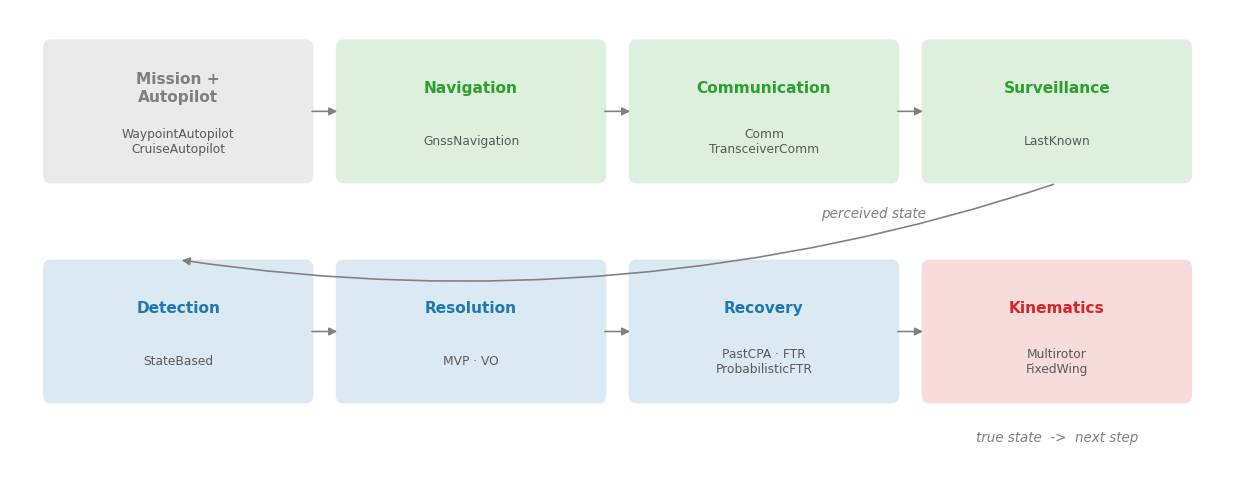

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = False

GUIDE, CNS, CDARR, PHYS = "#7f7f7f", "#2ca02c", "#1f77b4", "#d62728"
STAGES = [
    ("Mission +\nAutopilot", "WaypointAutopilot\nCruiseAutopilot", GUIDE),
    ("Navigation", "GnssNavigation", CNS),
    ("Communication", "Comm\nTransceiverComm", CNS),
    ("Surveillance", "LastKnown", CNS),
    ("Detection", "StateBased", CDARR),
    ("Resolution", "MVP · VO", CDARR),
    ("Recovery", "PastCPA · FTR\nProbabilisticFTR", CDARR),
    ("Kinematics", "Multirotor\nFixedWing", PHYS),
]

fig, ax = plt.subplots(figsize=(9.6, 3.8))
W, H = 2.05, 0.86
for k, (title, impls, colour) in enumerate(STAGES):
    col, row = k % 4, k // 4
    x, y = col * 2.35, -row * 1.5
    ax.add_patch(FancyBboxPatch((x, y), W, H, boxstyle="round,pad=0.06",
                                fc=colour, ec="none", alpha=0.16))
    ax.text(x + W / 2, y + H * 0.68, title, ha="center", va="center", fontsize=8.5, color=colour,
            fontweight="bold")
    ax.text(x + W / 2, y + H * 0.26, impls, ha="center", va="center", fontsize=6.8, color="0.35")
    if col < 3:
        ax.add_patch(FancyArrowPatch((x + W + 0.02, y + H / 2), (x + 2.33, y + H / 2),
                                     arrowstyle="-|>", mutation_scale=9, color="0.5", lw=0.9))

# the wrap from the end of the first row to the start of the second
ax.add_patch(FancyArrowPatch((3 * 2.35 + W / 2, -0.06), (W / 2, -1.5 + H + 0.06),
                             arrowstyle="-|>", mutation_scale=9, color="0.5", lw=0.9,
                             connectionstyle="arc3,rad=-0.12"))
ax.text(6.6, -0.30, "perceived state", ha="center", fontsize=7.5, color="0.5", style="italic")
ax.text(3 * 2.35 + W / 2, -1.82, "true state  ->  next step", ha="center", fontsize=7.5,
        color="0.5", style="italic")

ax.set_xlim(-0.3, 3 * 2.35 + W + 0.3)
ax.set_ylim(-2.0, 1.1)
ax.axis("off")
fig.tight_layout()

Two rules come out of that order, and they hold for the whole course:

1. The green and the blue boxes act on the **perceived** state. The measurement of the result uses
   the **true** state. The gap between them is what this platform exists to model.
2. To change a box, you give a different object to `run_fleet`. You do not edit the loop.

## 5. Find a name that the top level does not export

Walk the package when you do not know where a name lives. `pkgutil` lists every module without an
import of each one.

In [4]:
import pkgutil

modules = sorted(m.name for m in pkgutil.walk_packages(opencdarr.__path__, "opencdarr."))
print(f"{len(modules)} modules\n")

for name in modules:
    parts = name.split(".")
    if len(parts) == 2:
        print(f"\n{name}")
    else:
        print(f"    {parts[-1]}")

61 modules


opencdarr.autopilot
    base
    cruise
    waypoint

opencdarr.cache

opencdarr.cd
    base
    statebased

opencdarr.cns
    base
    broadcast
    communication
    hazard
    navigation
    noise_distributions
    stack
    surveillance

opencdarr.config

opencdarr.cr
    base
    mvp
    vo

opencdarr.crr
    base
    ftr
    pastcpa
    probabilistic_ftr

opencdarr.estimate
    ips
    montecarlo
    parallel

opencdarr.experiment
    backends
    card
    cell
    conditions
    declaration
    identity
    methods
    registry
    results

opencdarr.fleet

opencdarr.geo

opencdarr.kinematics
    base
    fixedwing
    multirotor

opencdarr.measurement

opencdarr.mission

opencdarr.performance

opencdarr.relative

opencdarr.rng

opencdarr.scenario
    base
    pairwise
    random_traffic
    ring

opencdarr.separation

opencdarr.state

opencdarr.viz

opencdarr.wind


To find the module that holds a name, search the docstrings instead of the file tree:

```python
help(opencdarr.cns.noise_distributions)      # what is in a module
import opencdarr.cr.mvp; print(opencdarr.cr.mvp.MVP.__doc__)   # what one class promises
```

Every module in this library starts with a docstring that says why it exists. Read that docstring
before you read its code.

## Do it yourself

1. Add a name to the sort in section 2 by hand, and check that your group agrees with the code.
2. Print the abstract methods of `NavigationModel`. Count them.
3. Find the module that holds `make_anisotropic_gaussian`. Import it and read its docstring.

## Check

1. `MVP` is in which group? `ConflictResolver` is in which group? Why do both exist?
2. Which two optional packages does the core install not need, and how does the library keep them
   optional?
3. Which boxes in the step diagram act on the perceived state?

## Next

Level 0 is complete. Level 1 starts at `L1.1 — The aircraft state`. Level 1 calls each module
directly, with no simulation loop.